# 01 Eksplorasi Data Klaim

Tujuan notebook ini: memahami data sebelum membuat prediksi, dan menentukan tiga hal yang akan
dipakai di notebook berikutnya.

1. Bulan klaim dihitung dari tanggal apa.
2. Apakah jumlah nasabah berubah selama periode data.
3. Seberapa besar pengaruh klaim bernilai sangat besar.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import klaim

pd.set_option("display.float_format", "{:,.1f}".format)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
JUTA = 1e6

In [2]:
k = klaim.muat_klaim()
p = klaim.muat_polis()
print("Klaim:", k.shape, "| Polis:", p.shape)
print("Klaim tanpa polis yang cocok:", (~k["Nomor Polis"].isin(p["Nomor Polis"])).sum())
k.isna().sum()[k.isna().sum() > 0]

Klaim: (4627, 14) | Polis: (4096, 6)
Klaim tanpa polis yang cocok: 0


Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64

Data lengkap untuk kolom utama. Yang kosong hanya sedikit: 37 klaim tanpa tanggal pembayaran dan
jenis perawatan, 6 tanpa kode ICD, dan 7 tanpa lokasi RS. Semua klaim terhubung ke data polis.

## 1. Bulan klaim dihitung dari tanggal apa

Ada tiga tanggal: pasien masuk RS, pasien keluar RS, dan pembayaran. Grafik di bawah menghitung
jumlah klaim per bulan dengan ketiganya.

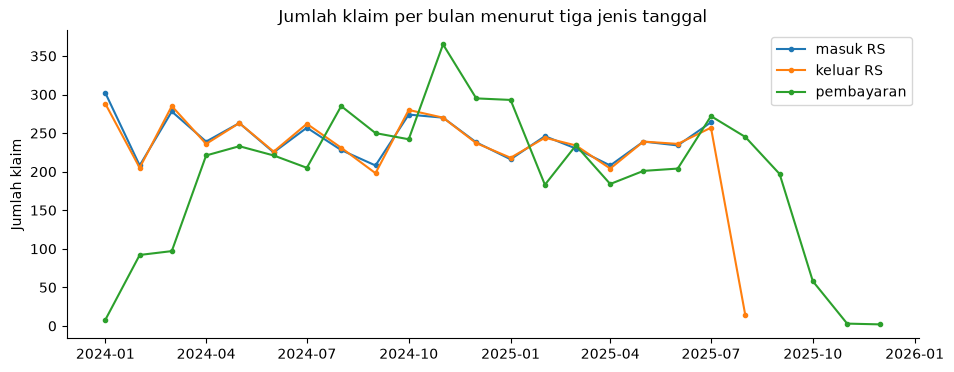

Jeda dari pasien keluar RS sampai klaim dibayar (hari):
count   4,590.0
mean       66.0
std        33.0
min         8.0
25%        45.0
50%        61.0
75%        81.0
90%       102.0
max       606.0
dtype: float64


In [3]:
fig, ax = plt.subplots()
for kolom, label in [("Tanggal Pasien Masuk RS", "masuk RS"), ("Tanggal Pasien Keluar RS", "keluar RS"),
                     ("Tanggal Pembayaran Klaim", "pembayaran")]:
    s = k.groupby(k[kolom].dt.to_period("M")).size()
    ax.plot(s.index.to_timestamp(), s.values, marker="o", ms=3, label=label)
ax.set_title("Jumlah klaim per bulan menurut tiga jenis tanggal")
ax.set_ylabel("Jumlah klaim")
ax.legend()
plt.show()

jeda = (k["Tanggal Pembayaran Klaim"] - k["Tanggal Pasien Keluar RS"]).dt.days
print("Jeda dari pasien keluar RS sampai klaim dibayar (hari):")
print(jeda.describe(percentiles=[.25, .5, .75, .9]).round(0))

Deret per tanggal masuk dan keluar RS hampir berimpit dan stabil. Deret per tanggal pembayaran
berbeda jauh di kedua ujungnya:

- **Awal 2024 rendah**, karena klaim yang pasiennya dirawat di akhir 2023 dan dibayar di awal 2024
  tidak ada di data.
- **Akhir 2025 anjlok**, karena klaim yang terjadi Juli 2025 masih banyak yang belum dibayar.

Median jeda dari pasien keluar sampai klaim dibayar sekitar dua bulan. Jadi naik turunnya deret per
tanggal bayar lebih banyak mencerminkan batas periode data, bukan perubahan jumlah klaim.

**Keputusan:** bulan klaim dihitung dari **tanggal pasien masuk RS**, yaitu saat kejadiannya.

## 2. Apakah jumlah nasabah berubah?

In [4]:
print("Tanggal efektif polis:", p["Tanggal Efektif Polis"].min().date(), "s.d.", p["Tanggal Efektif Polis"].max().date())
print(p["Tanggal Efektif Polis"].dt.year.value_counts().sort_index())

Tanggal efektif polis: 2011-12-05 s.d. 2018-02-20
Tanggal Efektif Polis
2011     42
2012    555
2013    725
2014    615
2015    701
2016    733
2017    657
2018     68
Name: count, dtype: int64


Semua 4.096 polis mulai berlaku antara 2011 dan 2018. Tidak ada polis baru selama periode klaim,
sehingga jumlah nasabah tetap. Naik turunnya jumlah klaim bukan karena pertambahan nasabah.

Karena seluruh nasabah makin tua setiap tahun, frekuensi klaim bisa pelan-pelan naik, tetapi dalam
19 bulan efek ini kecil dibanding naik turun bulanan.

## 3. Frekuensi, severity, dan total klaim per bulan

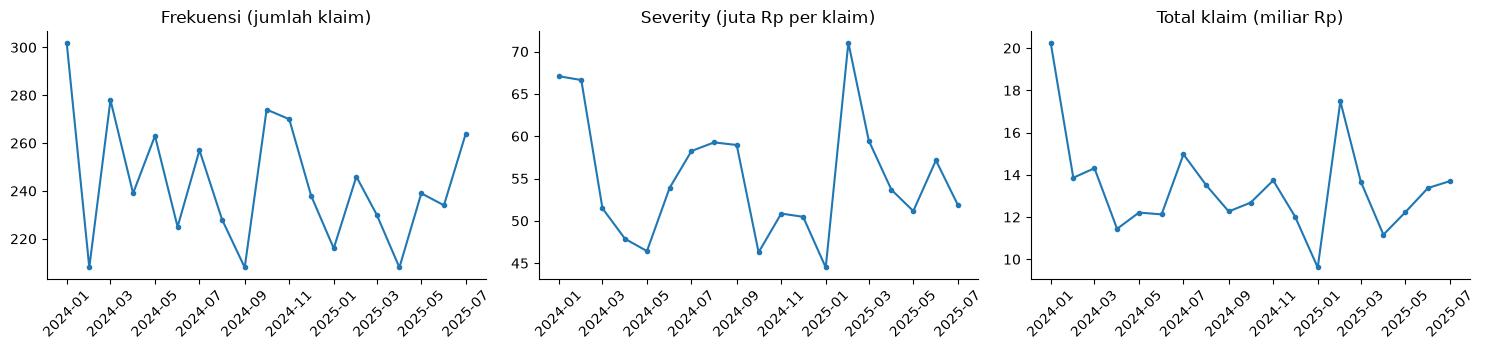

,Claim_Frequency,Severity (juta),Total (miliar)
bulan,,,
2024-01,302,67.1,20.3
2024-02,208,66.6,13.9
2024-03,278,51.5,14.3
2024-04,239,47.9,11.4
2024-05,263,46.4,12.2
2024-06,225,53.9,12.1
2024-07,257,58.3,15.0
2024-08,228,59.3,13.5
2024-09,208,59.0,12.3


In [5]:
g = klaim.per_bulan(k)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (kolom, judul, skala) in zip(axes, [("Claim_Frequency", "Frekuensi (jumlah klaim)", 1),
                                           ("Claim_Severity", "Severity (juta Rp per klaim)", JUTA),
                                           ("Total_Claim", "Total klaim (miliar Rp)", 1e9)]):
    ax.plot(g.index.to_timestamp(), g[kolom] / skala, marker="o", ms=3)
    ax.set_title(judul)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
(g.assign(Claim_Severity=g["Claim_Severity"] / JUTA, Total_Claim=g["Total_Claim"] / 1e9)
  .rename(columns={"Claim_Severity": "Severity (juta)", "Total_Claim": "Total (miliar)"}))

Frekuensi bergerak di kisaran 210 sampai 300 klaim per bulan tanpa tren yang jelas. Severity
lebih liar: turun ke Rp44 juta di Januari 2025, lalu melonjak ke Rp71 juta sebulan kemudian. Bagian
berikut menunjukkan penyebabnya.

## 4. Pengaruh klaim bernilai sangat besar

In [6]:
v = k[klaim.NILAI]
print("Kuantil nilai klaim (juta Rp):")
print((v.quantile([.5, .75, .9, .95, .99, .999]) / JUTA).round(1).rename(index=lambda q: f"persentil {q * 100:g}").to_string())

batas = v.quantile(.99)
k["di_atas_p99"] = (v - v.clip(upper=batas))
porsi = k.groupby("bulan")["di_atas_p99"].sum() / k.groupby("bulan")[klaim.NILAI].sum() * 100
print(f"\nBatas 1% klaim terbesar: Rp{batas / JUTA:,.0f} juta")
print("Porsi total bulanan yang berasal dari kelebihan di atas batas itu (%):")
print(porsi.round(1).to_string())

Kuantil nilai klaim (juta Rp):
persentil 50        14.5
persentil 75        51.1
persentil 90       132.8
persentil 95       223.3
persentil 99       633.7
persentil 99.9   1,498.3

Batas 1% klaim terbesar: Rp634 juta
Porsi total bulanan yang berasal dari kelebihan di atas batas itu (%):
bulan
2024-01    6.5
2024-02    8.8
2024-03    1.2
2024-04    2.0
2024-05    8.0
2024-06    0.0
2024-07    8.2
2024-08   11.5
2024-09    9.6
2024-10    0.0
2024-11    2.0
2024-12   12.3
2025-01    1.2
2025-02   17.9
2025-03   10.8
2025-04    5.4
2025-05    0.8
2025-06    9.8
2025-07    7.4
Freq: M


In [7]:
(k.nlargest(10, klaim.NILAI)
  [["bulan", klaim.NILAI, "Inpatient/Outpatient", "Lokasi RS", "ICD Description"]]
  .assign(**{klaim.NILAI: lambda d: d[klaim.NILAI] / JUTA})
  .rename(columns={klaim.NILAI: "Nilai (juta Rp)"}))

,bulan,Nilai (juta Rp),Inpatient/Outpatient,Lokasi RS,ICD Description
324,2025-02,"2,197.5",IP,Singapore,CORONARY ATRIAL DISEASES (CAD)
367,2025-06,"1,938.4",IP,Singapore,CORONARY ATRIAL DISEASES (CAD)
252,2024-09,"1,813.0",IP,Singapore,MALIGNANT NEOPLASM OF PROSTAT
964,2024-02,"1,756.4",IP,Singapore,ACIDOSIS
2104,2025-07,"1,643.4",IP,Singapore,"Hemangioma and lymphangioma, any site"
1483,2025-02,"1,411.7",IP,Singapore,Fracture of other metacarpal bone
904,2024-08,"1,411.1",IP,Indonesia,"MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED"
379,2024-05,"1,404.8",IP,Overseas,"MALIGNANT NEOPLASM, LOWER LOBE, BRONCHUS OR LUNG"
1504,2024-12,"1,352.4",IP,Singapore,Other specified pleural conditions
2585,2024-01,"1,290.8",IP,Singapore,"PERIPHERAL VASCULAR DISEASE, UNSPECIFIED"


Median klaim hanya sekitar Rp14 juta, tetapi 1% klaim terbesar bernilai di atas Rp600 juta, dan
yang terbesar Rp2,2 miliar. Di bulan Februari 2025, kelebihan dari klaim-klaim besar ini menyumbang
hampir 18% total bulanan. Sembilan dari sepuluh klaim terbesar adalah rawat inap di luar Indonesia,
kebanyakan di Singapura.

Artinya, severity bulanan sangat dipengaruhi apakah bulan itu kebetulan berisi satu atau dua klaim
raksasa. Kejadian seperti ini hampir mustahil ditebak per bulan, jadi model yang realistis adalah
model yang tidak bereaksi berlebihan terhadap lonjakan sesaat.

## 5. Siapa yang mengajukan klaim

In [8]:
per_polis = k.groupby("Nomor Polis").size()
print(f"Polis yang pernah klaim: {per_polis.size:,} dari {len(p):,} ({per_polis.size / len(p):.0%})")
urut = per_polis.sort_values(ascending=False)
print(f"10 polis dengan klaim terbanyak menyumbang {urut.head(10).sum() / len(k):.1%} seluruh klaim")
print("Klaim terbanyak dari satu polis:", urut.iloc[0])

kp = k.merge(p, on="Nomor Polis", how="left")
ringkas = lambda d: pd.Series({"jumlah klaim": len(d), "rata-rata (juta)": d[klaim.NILAI].mean() / JUTA,
                                "median (juta)": d[klaim.NILAI].median() / JUTA,
                                "porsi total": d[klaim.NILAI].sum() / k[klaim.NILAI].sum() * 100})
for kolom in ["Plan Code", "Inpatient/Outpatient", "Lokasi RS"]:
    display(kp.groupby(kolom).apply(ringkas, include_groups=False).sort_values("jumlah klaim", ascending=False))

Polis yang pernah klaim: 1,210 dari 4,096 (30%)
10 polis dengan klaim terbanyak menyumbang 17.9% seluruh klaim
Klaim terbanyak dari satu polis: 222


,jumlah klaim,rata-rata (juta),median (juta),porsi total
Plan Code,,,,
M-002,"3,028.0",56.6,13.6,67.3
M-003,895.0,44.7,18.4,15.7
M-001,704.0,61.4,14.0,17.0


,jumlah klaim,rata-rata (juta),median (juta),porsi total
Inpatient/Outpatient,,,,
IP,"2,258.0",83.5,26.7,74.0
OP,"1,940.0",23.4,2.7,17.8
ODC,281.0,59.5,37.2,6.6
ODS,111.0,30.6,16.6,1.3


,jumlah klaim,rata-rata (juta),median (juta),porsi total
Lokasi RS,,,,
Indonesia,"3,102.0",33.7,8.7,41.1
Singapore,"1,019.0",124.7,52.6,49.9
Malaysia,456.0,39.1,16.8,7.0
Overseas,28.0,149.2,39.5,1.6
Others,6.0,57.4,16.5,0.1
Taiwan,5.0,14.7,13.6,0.0
Hong Kong,1.0,10.6,10.6,0.0
Australia,1.0,66.4,66.4,0.0
Japan,1.0,162.2,162.2,0.1


- Hanya sekitar 30% polis yang pernah mengajukan klaim, dan klaim sangat terpusat: satu polis saja
  mengajukan 222 klaim dalam 19 bulan.
- Rawat inap (IP) rata-rata bernilai lebih dari tiga kali rawat jalan (OP).
- Klaim di Singapura hanya 22% dari jumlah klaim, tetapi menyumbang 50% total nilai klaim. Rata-rata
  klaim di Singapura Rp125 juta, hampir empat kali Indonesia (Rp34 juta). Malaysia tidak jauh berbeda
  dari Indonesia.

## Kesimpulan untuk tahap berikutnya

1. Bulan klaim memakai tanggal pasien masuk RS.
2. Jumlah nasabah tetap, jadi tidak perlu menyesuaikan prediksi dengan pertumbuhan nasabah.
3. Deret bulanan hanya 19 titik dan severity dipengaruhi klaim raksasa yang acak. Model rumit mudah
   salah menangkap lonjakan sesaat sebagai pola. Notebook 02 menguji apakah metode sederhana
   justru lebih baik.